In [ ]:
import mrpro

filename = "meas_MID00018_FID110986_COR_PD_FS.h5"
path = f"/data/datasets/msk_mri_debug/h5/{filename}"

kdata = mrpro.data.KData.from_file(path,
    mrpro.data.traj_calculators.KTrajectoryCartesian(),
)

In [3]:
print(kdata)

KData on device "cpu" with (broadcasted) shape [42, 15, 1, 231, 768].
  data: Tensor<42, 15, 1, 231, 768>, |x| ∈ [2.33e-10, 0.00274], μ=-3.21e-09+4.95e-09j, [ 5.3502e-06-3.8184e-07j,  5.1130e-06+2.5705e-07j,  ..., -7.2243e-06-2.6333e-06j, -6.8247e-06+1.4002e-06j]
  traj: KTrajectory on device "cpu" with (broadcasted) shape [1, 1, 1, 231, 768].
     kz: Tensor<1, 1, 1, 1, 1>, constant 0
     ky: Tensor<1, 1, 1, 231, 1>, x ∈ [-230, 230], μ=0, [-230., -228.,  ...,  228.,  230.]
     kx: Tensor<1, 1, 1, 1, 768>, x ∈ [-384, 383], μ=-0.5, [-384., -383.,  ...,  382.,  383.]
     grid_detection_tolerance: 0.001
     repeat_detection_tolerance: 0.001
  header:  KHeader on device "cpu" with (broadcasted) shape [42, 1, 1, 231, 1].
     recon_matrix: z=1, y=384, x=384
     encoding_matrix: z=1, y=576, x=768
     recon_fov: z=0.0025, y=0.15, x=0.15
     encoding_fov: z=0.00375, y=0.225149994, x=0.3
     acq_info: AcqInfo<42, 1, 1, 231, 1>
     trajectory: KTrajectoryCartesian()
     lamor_frequency

In [6]:
fft_op = mrpro.operators.FastFourierOp(
    dim=(-2, -1),
    recon_matrix=kdata.header.recon_matrix,
    encoding_matrix=kdata.header.encoding_matrix,
)
(img,) = fft_op.adjoint(kdata.data)

In [10]:
img.shape

torch.Size([42, 15, 1, 384, 384])

In [ ]:
import matplotlib.pyplot as plt
import torch


def show_images(*images: torch.Tensor, titles: list[str] | None = None) -> None:
    """Plot images."""
    n_images = len(images)
    _, axes = plt.subplots(1, n_images, squeeze=False, figsize=(n_images * 3, 3), dpi=200)
    for i in range(n_images):
        # axes[0][i].imshow(images[i], cmap='gray', vmin=0, vmax=images[i].max() * 0.6)
        axes[0][i].imshow(images[i], cmap='gray')
        axes[0][i].axis('off')
        if titles:
            axes[0][i].set_title(titles[i])
    plt.show()

torch.Size([42, 384, 384])


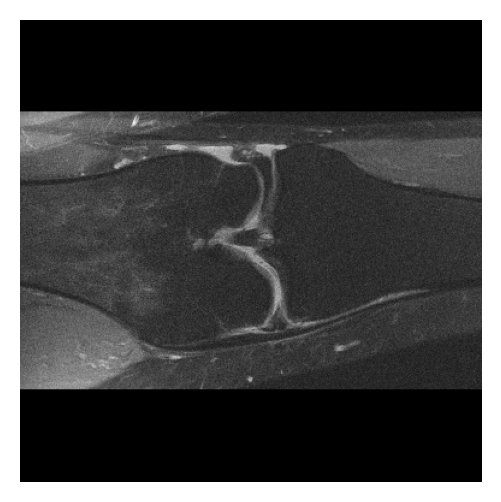

In [ ]:
# Combine data from different coils and show magnitude image
magnitude_fully_sampled = img.abs().square().sum(dim=-4).sqrt().squeeze()
print(magnitude_fully_sampled.shape)
show_images(magnitude_fully_sampled[10])

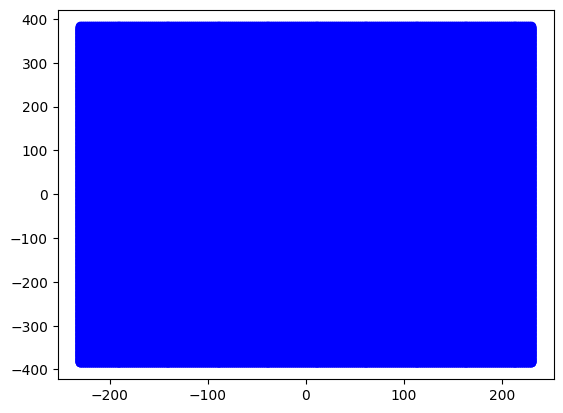

In [29]:
# Plot the fully sampled trajectory (in blue)
full_kz, full_ky, full_kx = kdata.traj.as_tensor()
plt.plot(full_ky[0, 0].flatten(), full_kx[0, 0].flatten(), 'ob')

plt.show()

In [30]:
reconstruction = mrpro.algorithms.reconstruction.DirectReconstruction(kdata)
img = reconstruction(kdata)

/home/berk/miniconda3/envs/mri/lib/python3.10/site-packages/matplotlib/cbook.py:684: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  x = np.array(x, subok=True, copy=copy)


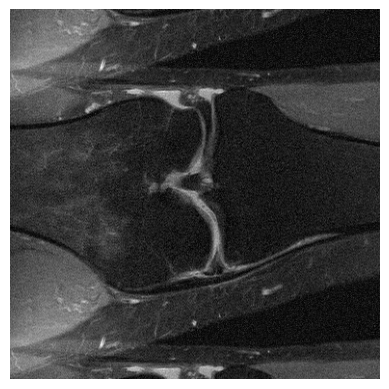

In [35]:
import matplotlib.pyplot as plt

# If there are multiple slices, ..., only the first one is selected
first_img = img.rss().squeeze()[10]  #  images, z, y, x
plt.imshow(first_img, cmap='gray')
plt.axis('off')
plt.show()